# 🎵 Notebook 06: FMA Balanced Training (14 Genres)

## Overview
This notebook improves on Notebook 05 with **class balancing techniques**:

## Improvements Applied
| Change | Effect |
|--------|--------|
| Remove Easy Listening (21) + International (18) | ↓ 14 genres (cleaner) |
| `class_weight='balanced'` on RF, SVM, XGBoost, MLP | ↑ Minority class focus |
| Cap Rock at 2500, Electronic at 2500 | ↓ Majority class dominance |
| SMOTE on classes < 200 samples | ↑ Minority class data |

## Genre Distribution (After Balancing)
**Removed:** Easy Listening (21), International (18) - too few samples

**Undersampled:**
- Rock: 6,103 → 2,500
- Electronic: 5,314 → 2,500

**SMOTE Oversampled (< 200 samples):**
- Pop: 186 → 300
- Country: 178 → 300
- Soul-RnB: 154 → 300
- Spoken: 118 → 300
- Blues: 74 → 300

## 1. Setup & Imports

In [4]:
import os
import pickle
import warnings
import time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.utils import resample

# Models
from sklearn.svm import SVC
from sklearn.ensemble import HistGradientBoostingClassifier, VotingClassifier, RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# SMOTE for oversampling
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
    print("✅ SMOTE (imbalanced-learn) available")
except ImportError:
    SMOTE_AVAILABLE = False
    print("⚠️ imbalanced-learn not installed. Run: pip install imbalanced-learn")

# XGBoost
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("✅ XGBoost available")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️ XGBoost not installed. Run: pip install xgboost")

# Paths
BASE_DIR = os.path.dirname(os.getcwd())
DATA_DIR = os.path.join(BASE_DIR, 'data')
FMA_META_DIR = os.path.join(DATA_DIR, 'fma_small', 'fma_metadata')
ARTIFACTS_DIR = os.path.join(BASE_DIR, 'artifacts')

print(f"\nBASE_DIR: {BASE_DIR}")
print(f"FMA_META_DIR: {FMA_META_DIR}")
print(f"ARTIFACTS_DIR: {ARTIFACTS_DIR}")

✅ SMOTE (imbalanced-learn) available
✅ XGBoost available

BASE_DIR: c:\Users\sophi\Desktop\Ynov\Cours\Concepts_technos_IA\MLDeploy
FMA_META_DIR: c:\Users\sophi\Desktop\Ynov\Cours\Concepts_technos_IA\MLDeploy\data\fma_small\fma_metadata
ARTIFACTS_DIR: c:\Users\sophi\Desktop\Ynov\Cours\Concepts_technos_IA\MLDeploy\artifacts


In [5]:
# Install imbalanced-learn if needed
if not SMOTE_AVAILABLE:
    print("Installing imbalanced-learn...")
    !pip install imbalanced-learn -q
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
    print("✅ SMOTE installed and imported")

## 2. Load FMA Medium Data (Reuse Pre-computed Features)

In [6]:
# Load tracks metadata
tracks = pd.read_csv(os.path.join(FMA_META_DIR, 'tracks.csv'), index_col=0, header=[0, 1])

# Load pre-computed features (518 features - NO RE-EXTRACTION NEEDED!)
features = pd.read_csv(os.path.join(FMA_META_DIR, 'features.csv'), index_col=0, header=[0, 1, 2])

print(f"Tracks metadata: {tracks.shape}")
print(f"Features: {features.shape}")
print("\n✅ Reusing pre-computed FMA features (no extraction needed)")

Tracks metadata: (106574, 52)
Features: (106574, 518)

✅ Reusing pre-computed FMA features (no extraction needed)


In [7]:
# Filter to MEDIUM subset only
medium_mask = tracks[('set', 'subset')] == 'medium'
medium_track_ids = tracks[medium_mask].index

print(f"Medium subset tracks: {len(medium_track_ids):,}")

# Get common IDs between features and medium tracks
common_ids = medium_track_ids.intersection(features.index)
print(f"Tracks with features: {len(common_ids):,}")

Medium subset tracks: 17,000
Tracks with features: 17,000


In [8]:
# Filter features to medium subset
X_features = features.loc[common_ids].copy()

# Flatten multi-level column names: (feature, stat, number) -> feature_stat_number
X_features.columns = ['_'.join(map(str, col)).strip() for col in X_features.columns.values]

print(f"Features shape: {X_features.shape}")
print(f"Feature columns: {len(X_features.columns)}")

Features shape: (17000, 518)
Feature columns: 518


In [9]:
# Get genre labels for medium subset
y_genres = tracks.loc[common_ids, ('track', 'genre_top')]

# Remove tracks with missing genres
valid_mask = y_genres.notna()
X_features = X_features[valid_mask]
y_genres = y_genres[valid_mask]

print(f"Tracks with valid genres: {len(y_genres):,}")
print(f"\nOriginal Genre distribution:")
genre_counts = y_genres.value_counts()
for genre, count in genre_counts.items():
    print(f"  {genre}: {count:,} ({100*count/len(y_genres):.1f}%)")

Tracks with valid genres: 17,000

Original Genre distribution:
  Rock: 6,103 (35.9%)
  Electronic: 5,314 (31.3%)
  Experimental: 1,251 (7.4%)
  Hip-Hop: 1,201 (7.1%)
  Classical: 619 (3.6%)
  Folk: 519 (3.1%)
  Old-Time / Historic: 510 (3.0%)
  Jazz: 384 (2.3%)
  Instrumental: 350 (2.1%)
  Pop: 186 (1.1%)
  Country: 178 (1.0%)
  Soul-RnB: 154 (0.9%)
  Spoken: 118 (0.7%)
  Blues: 74 (0.4%)
  Easy Listening: 21 (0.1%)
  International: 18 (0.1%)


## 3. Data Balancing Strategy

In [10]:
# === STEP 1: Remove tiny genres (< 50 samples) ===
GENRES_TO_REMOVE = ['Easy Listening', 'International']

print("=" * 60)
print("STEP 1: Remove tiny genres")
print("=" * 60)

for genre in GENRES_TO_REMOVE:
    count = genre_counts.get(genre, 0)
    print(f"  Removing: {genre} ({count} samples)")

# Filter out tiny genres
keep_mask = ~y_genres.isin(GENRES_TO_REMOVE)
X_features = X_features[keep_mask]
y_genres = y_genres[keep_mask]

print(f"\nRemaining: {len(y_genres):,} tracks, {y_genres.nunique()} genres")

STEP 1: Remove tiny genres
  Removing: Easy Listening (21 samples)
  Removing: International (18 samples)

Remaining: 16,961 tracks, 14 genres


In [ ]:
# === STEP 2: Undersample majority classes ===
# Keep majority classes high enough that SMOTE targets aren't too far below them
UNDERSAMPLE_CAPS = {
    'Experimental': 3000,
    'Rock': 3000,
    'Electronic': 3000,
}

print("=" * 60)
print("STEP 2: Undersample majority classes")
print("=" * 60)

df = X_features.copy()
df['genre'] = y_genres

balanced_dfs = []
for genre in df['genre'].unique():
    genre_df = df[df['genre'] == genre]
    if genre in UNDERSAMPLE_CAPS and len(genre_df) > UNDERSAMPLE_CAPS[genre]:
        genre_df = resample(genre_df, n_samples=UNDERSAMPLE_CAPS[genre], random_state=42, replace=False)
        print(f"  {genre}: {len(df[df['genre'] == genre]):,} → {len(genre_df):,} (undersampled)")
    else:
        print(f"  {genre}: {len(genre_df):,} (unchanged)")
    balanced_dfs.append(genre_df)

df = pd.concat(balanced_dfs, ignore_index=True)
print(f"\nAfter undersampling: {len(df):,} tracks")


In [12]:
# Handle NaN/Inf values before SMOTE
feature_cols = [c for c in df.columns if c != 'genre']
X_balanced = df[feature_cols].copy()
y_balanced = df['genre'].copy()

print(f"NaN values before: {X_balanced.isna().sum().sum():,}")
print(f"Inf values before: {np.isinf(X_balanced.values).sum():,}")

# Replace inf with NaN, then fill with median
X_balanced = X_balanced.replace([np.inf, -np.inf], np.nan)
X_balanced = X_balanced.fillna(X_balanced.median())
X_balanced = X_balanced.fillna(0)  # For columns that were all NaN

print(f"NaN values after: {X_balanced.isna().sum().sum():,}")

NaN values before: 0
Inf values before: 0
NaN values after: 0


In [ ]:
# === STEP 3: SMOTE for minority classes ===
# Target: bring all genres to ~1500 so the gap vs majority (3000) is only 2x, not 8x
# No class_weight will be used in models — SMOTE alone handles imbalance
SMOTE_TARGET = 1500
SMOTE_THRESHOLD = 2000  # Apply SMOTE to any genre below this

print("=" * 60)
print("STEP 3: SMOTE oversample minority classes")
print("=" * 60)

current_counts = y_balanced.value_counts()
print("\nSMOTE targets:")
for genre, count in current_counts.items():
    if count < SMOTE_THRESHOLD:
        print(f"  {genre}: {count} → {SMOTE_TARGET}")
    else:
        print(f"  {genre}: {count} (no SMOTE needed)")

le = LabelEncoder()
y_encoded = le.fit_transform(y_balanced)

sampling_strategy = {}
for i, genre in enumerate(le.classes_):
    count = current_counts[genre]
    if count < SMOTE_THRESHOLD:
        target = min(SMOTE_TARGET, current_counts.max())  # never exceed largest class
        sampling_strategy[i] = target

print(f"\nApplying SMOTE...")
smote = SMOTE(sampling_strategy=sampling_strategy, random_state=42, k_neighbors=5)
X_resampled, y_resampled = smote.fit_resample(X_balanced.values, y_encoded)

print(f"\nAfter SMOTE: {len(X_resampled):,} samples")
final_counts = pd.Series(y_resampled).map(lambda x: le.classes_[x]).value_counts()
for genre, count in final_counts.sort_values().items():
    print(f"  {genre:20s}: {count:,}")


In [14]:
# Visualize final distribution
final_counts = pd.Series(y_resampled).map(lambda x: le.classes_[x]).value_counts().sort_values(ascending=False)

print("\n" + "=" * 60)
print("FINAL GENRE DISTRIBUTION")
print("=" * 60)
for genre, count in final_counts.items():
    bar = "█" * int(count / 100)
    print(f"  {genre:20s}: {count:5,} {bar}")

print(f"\nTotal: {len(X_resampled):,} samples, {len(le.classes_)} genres")


FINAL GENRE DISTRIBUTION
  Rock                : 2,500 █████████████████████████
  Electronic          : 2,500 █████████████████████████
  Experimental        : 1,251 ████████████
  Hip-Hop             : 1,201 ████████████
  Classical           :   619 ██████
  Folk                :   519 █████
  Old-Time / Historic :   510 █████
  Jazz                :   384 ███
  Instrumental        :   350 ███
  Soul-RnB            :   300 ███
  Pop                 :   300 ███
  Blues               :   300 ███
  Spoken              :   300 ███
  Country             :   300 ███

Total: 11,334 samples, 14 genres


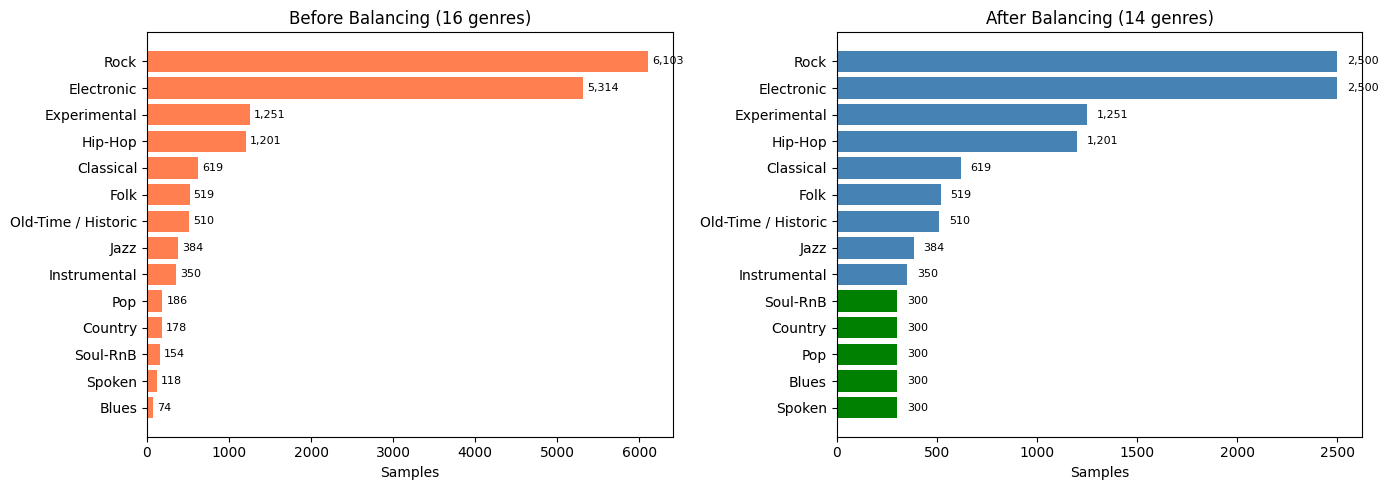

In [15]:
# Visualize before vs after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
original_counts = genre_counts.drop(GENRES_TO_REMOVE, errors='ignore').sort_values(ascending=True)
axes[0].barh(original_counts.index, original_counts.values, color='coral')
axes[0].set_xlabel('Samples')
axes[0].set_title('Before Balancing (16 genres)')
for i, (genre, count) in enumerate(original_counts.items()):
    axes[0].text(count + 50, i, f'{count:,}', va='center', fontsize=8)

# After
final_counts_sorted = final_counts.sort_values(ascending=True)
colors = ['green' if final_counts_sorted[g] > original_counts.get(g, 0) else 'steelblue' 
          for g in final_counts_sorted.index]
axes[1].barh(final_counts_sorted.index, final_counts_sorted.values, color=colors)
axes[1].set_xlabel('Samples')
axes[1].set_title('After Balancing (14 genres)')
for i, (genre, count) in enumerate(final_counts_sorted.items()):
    axes[1].text(count + 50, i, f'{count:,}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'fma_balanced_distribution.png'), dpi=150)
plt.show()

## 4. Prepare Data for Training

In [16]:
# Use resampled data
X = X_resampled
y = y_resampled

print(f"Total features: {len(feature_cols)}")
print(f"\nClasses ({len(le.classes_)}):")
for i, cls in enumerate(le.classes_):
    print(f"  {i}: {cls}")

Total features: 518

Classes (14):
  0: Blues
  1: Classical
  2: Country
  3: Electronic
  4: Experimental
  5: Folk
  6: Hip-Hop
  7: Instrumental
  8: Jazz
  9: Old-Time / Historic
  10: Pop
  11: Rock
  12: Soul-RnB
  13: Spoken


In [17]:
# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set: {X_test.shape[0]:,} samples")

Training set: 9,067 samples
Test set: 2,267 samples


In [18]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Features scaled")

✅ Features scaled


## 5. Train Models (With Class Weighting)

**Key improvements:**
- `class_weight='balanced'` on RF, SVM (auto-adjusts weights inversely proportional to class frequencies)
- XGBoost uses `scale_pos_weight` internally when class weights are provided
- Balanced data from SMOTE + undersampling

In [ ]:
# Cross-validation setup
# NOTE: NO class_weight here — SMOTE already balanced the data.
# Using class_weight on top of SMOTE double-penalises the majority and causes
# the model to hedge toward Experimental/catch-all genres.
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=25, random_state=42, n_jobs=-1
        # no class_weight — SMOTE handles it
    ),
    'Hist Gradient Boosting': HistGradientBoostingClassifier(
        max_iter=200, max_depth=10, learning_rate=0.1, random_state=42
        # no class_weight
    ),
    'MLP Neural Net': MLPClassifier(
        hidden_layer_sizes=(256, 128, 64), alpha=0.001, max_iter=400, random_state=42
    ),
}

if XGBOOST_AVAILABLE:
    models['XGBoost'] = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='mlogloss',
        n_jobs=-1
    )

# SVM: no class_weight
models['SVM (RBF)'] = SVC(
    kernel='rbf', C=10, gamma='scale', random_state=42, probability=True
    # no class_weight
)

print(f"Training {len(models)} models...")
print("⚡ Using SMOTE-balanced data only — NO class_weight (avoids double-balancing)")
print("⏳ SVM will be slowest - runs last")


In [20]:
# Train and evaluate each model
results = []

for name, model in models.items():
    print(f"Training {name}...", end=' ', flush=True)
    start = time.time()
    
    # Cross-validation
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    
    # Fit on full training set
    model.fit(X_train_scaled, y_train)
    
    # Test accuracy
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
    elapsed = time.time() - start
    
    results.append({
        'Model': name,
        'CV Mean': scores.mean(),
        'CV Std': scores.std(),
        'Test Acc': test_acc,
        'Time (s)': elapsed
    })
    
    print(f"✅ CV: {scores.mean():.4f} (±{scores.std():.4f}) | Test: {test_acc:.4f} | {elapsed:.1f}s")

results_df = pd.DataFrame(results).sort_values('Test Acc', ascending=False)
print("\n" + "="*70)
display(results_df)

Training Random Forest... ✅ CV: 0.6386 (±0.0069) | Test: 0.6502 | 26.4s
Training Hist Gradient Boosting... ✅ CV: 0.7043 (±0.0085) | Test: 0.7239 | 363.6s
Training MLP Neural Net... ✅ CV: 0.6754 (±0.0031) | Test: 0.6965 | 36.6s
Training XGBoost... ✅ CV: 0.6915 (±0.0118) | Test: 0.7080 | 342.0s
Training SVM (RBF)... ✅ CV: 0.7213 (±0.0067) | Test: 0.7455 | 261.7s



,Model,CV Mean,CV Std,Test Acc,Time (s)
4,SVM (RBF),0.721298,0.006718,0.745479,261.667597
1,Hist Gradient Boosting,0.704313,0.008540,0.723864,363.616986
3,XGBoost,0.691520,0.011761,0.707984,341.988688
2,MLP Neural Net,0.675417,0.003082,0.696515,36.614317
0,Random Forest,0.638580,0.006920,0.650199,26.417863


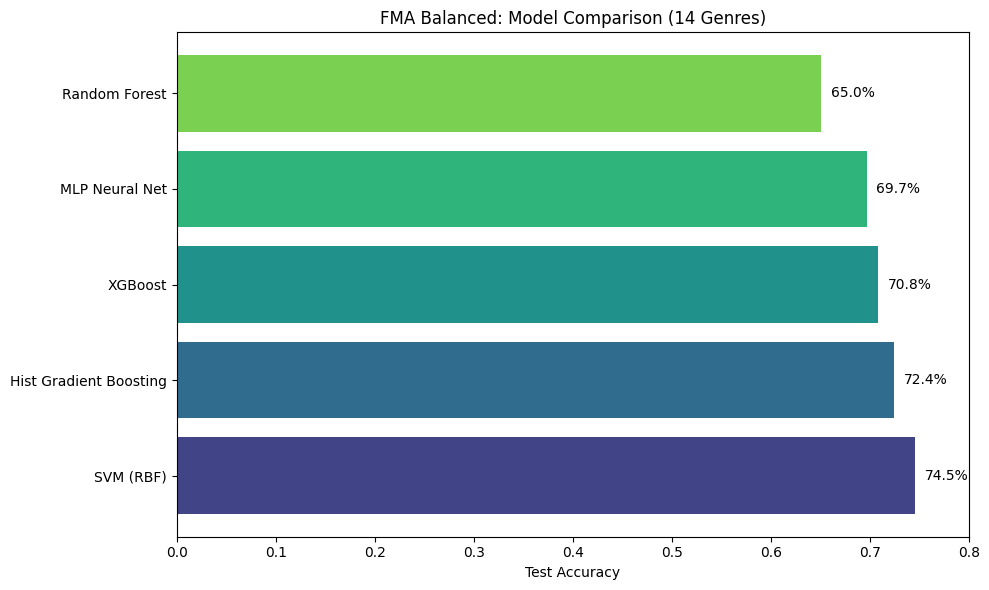

In [21]:
# Visualize results
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(results_df)))

bars = ax.barh(results_df['Model'], results_df['Test Acc'], color=colors)
ax.set_xlabel('Test Accuracy')
ax.set_title('FMA Balanced: Model Comparison (14 Genres)')
ax.set_xlim(0, 0.8)

for bar, acc in zip(bars, results_df['Test Acc']):
    ax.text(acc + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{acc:.1%}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'fma_balanced_model_comparison.png'), dpi=150)
plt.show()

## 6. Hyperparameter Tuning (Top 3)

In [22]:
# Get top 3 models for tuning
top_models = results_df.head(3)['Model'].tolist()
print(f"Tuning top 3 models: {top_models}")

Tuning top 3 models: ['SVM (RBF)', 'Hist Gradient Boosting', 'XGBoost']


In [24]:
# Define parameter grids (MINIMAL for speed)
param_grids = {
    'SVM (RBF)': {
        'C': [1, 10, 50],
        'gamma': ['scale', 'auto']
    },
    'XGBoost': {
        'n_estimators': [100, 200],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.1, 0.2]
    },
    'Hist Gradient Boosting': {
        'max_iter': [100, 200],
        'max_depth': [8, 12],
        'learning_rate': [0.1, 0.2]
    },
    'MLP Neural Net': {
        'hidden_layer_sizes': [(128, 64), (256, 128)],
        'alpha': [0.001, 0.01]
    },
    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [15, 25]
    }
}

# Base model templates for tuning (NO probability=True for SVM - faster tuning)
# class_weight='balanced' preserved for models that support it
base_model_templates = {
    'SVM (RBF)': SVC(random_state=42, class_weight='balanced'),  # NO probability during tuning
    'XGBoost': XGBClassifier(eval_metric='mlogloss', n_jobs=5, random_state=42) if XGBOOST_AVAILABLE else None,
    'Hist Gradient Boosting': HistGradientBoostingClassifier(random_state=42, class_weight='balanced'),
    'MLP Neural Net': MLPClassifier(max_iter=300, random_state=42),
    'Random Forest': RandomForestClassifier(n_jobs=5, random_state=42, class_weight='balanced')
}

tuned_models = {}
tuning_results = []

for name in top_models:
    if name not in param_grids:
        print(f"⚠️ No param grid for {name}, using default")
        tuned_models[name] = models[name]
        tuning_results.append({'Model': name, 'Test Acc': results_df[results_df['Model']==name]['Test Acc'].values[0], 'Best Params': 'default'})
        continue
    
    if base_model_templates.get(name) is None:
        print(f"⚠️ No base template for {name}, using default")
        tuned_models[name] = models[name]
        tuning_results.append({'Model': name, 'Test Acc': results_df[results_df['Model']==name]['Test Acc'].values[0], 'Best Params': 'default'})
        continue
        
    print(f"\nTuning {name}...", flush=True)
    start = time.time()
    
    # Use template to preserve class_weight
    base_model = base_model_templates[name]
    
    grid = GridSearchCV(
        base_model,
        param_grids[name],
        cv=3,
        scoring='accuracy',
        n_jobs=5,  # LIMITED TO 5 CORES
        verbose=1
    )
    
    grid.fit(X_train_scaled, y_train)
    
    # Get best params
    best_params = grid.best_params_
    
    # For SVM: retrain with probability=True (needed for soft voting ensemble)
    if name == 'SVM (RBF)':
        print(f"  Retraining SVM with probability=True...")
        final_model = SVC(
            **best_params,
            random_state=42,
            class_weight='balanced',
            probability=True  # Add probability for ensemble
        )
        final_model.fit(X_train_scaled, y_train)
        tuned_models[name] = final_model
    else:
        tuned_models[name] = grid.best_estimator_
    
    test_acc = accuracy_score(y_test, tuned_models[name].predict(X_test_scaled))
    elapsed = time.time() - start
    
    tuning_results.append({
        'Model': name,
        'Test Acc': test_acc,
        'Best Params': best_params
    })
    
    print(f"✅ {name}: {test_acc:.4f} with {best_params} ({elapsed:.1f}s)")


Tuning SVM (RBF)...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
  Retraining SVM with probability=True...
✅ SVM (RBF): 0.7455 with {'C': 10, 'gamma': 'auto'} (402.2s)

Tuning Hist Gradient Boosting...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
✅ Hist Gradient Boosting: 0.7265 with {'learning_rate': 0.1, 'max_depth': 8, 'max_iter': 200} (1744.1s)

Tuning XGBoost...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
✅ XGBoost: 0.7164 with {'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200} (2301.3s)


In [25]:
# Show tuning results
tuning_df = pd.DataFrame(tuning_results).sort_values('Test Acc', ascending=False)
print("\n🏆 TUNING RESULTS")
display(tuning_df)


🏆 TUNING RESULTS


,Model,Test Acc,Best Params
0,SVM (RBF),0.745479,"{'C': 10, 'gamma': 'auto'}"
1,Hist Gradient Boosting,0.726511,"{'learning_rate': 0.1, 'max_depth': 8, 'max_it..."
2,XGBoost,0.716365,"{'learning_rate': 0.2, 'max_depth': 4, 'n_esti..."


## 7. Create Ensemble

In [26]:
# Create ensemble from tuned models
estimators = [(name, model) for name, model in tuned_models.items()]

ensemble = VotingClassifier(
    estimators=estimators,
    voting='soft'
)

print(f"Training ensemble with {len(estimators)} models...")
ensemble.fit(X_train_scaled, y_train)

ensemble_test_acc = accuracy_score(y_test, ensemble.predict(X_test_scaled))
print(f"✅ Ensemble Test Accuracy: {ensemble_test_acc:.4f}")

Training ensemble with 3 models...
✅ Ensemble Test Accuracy: 0.7380


In [27]:
# Compare all final models
all_results = tuning_results.copy()
all_results.append({'Model': 'Ensemble', 'Test Acc': ensemble_test_acc, 'Best Params': 'voting=soft'})

all_results_df = pd.DataFrame(all_results).sort_values('Test Acc', ascending=False)
print("\n🏆 FINAL RESULTS")
display(all_results_df)


🏆 FINAL RESULTS


,Model,Test Acc,Best Params
0,SVM (RBF),0.745479,"{'C': 10, 'gamma': 'auto'}"
3,Ensemble,0.737980,voting=soft
1,Hist Gradient Boosting,0.726511,"{'learning_rate': 0.1, 'max_depth': 8, 'max_it..."
2,XGBoost,0.716365,"{'learning_rate': 0.2, 'max_depth': 4, 'n_esti..."


## 8. Confusion Matrix & Per-Class Analysis

In [28]:
# Select best model
best_model_name = all_results_df.iloc[0]['Model']
best_model = ensemble if best_model_name == 'Ensemble' else tuned_models.get(best_model_name, models[best_model_name])
best_test_acc = all_results_df.iloc[0]['Test Acc']

print(f"\n🏆 Best Model: {best_model_name} ({best_test_acc:.1%})")


🏆 Best Model: SVM (RBF) (74.5%)


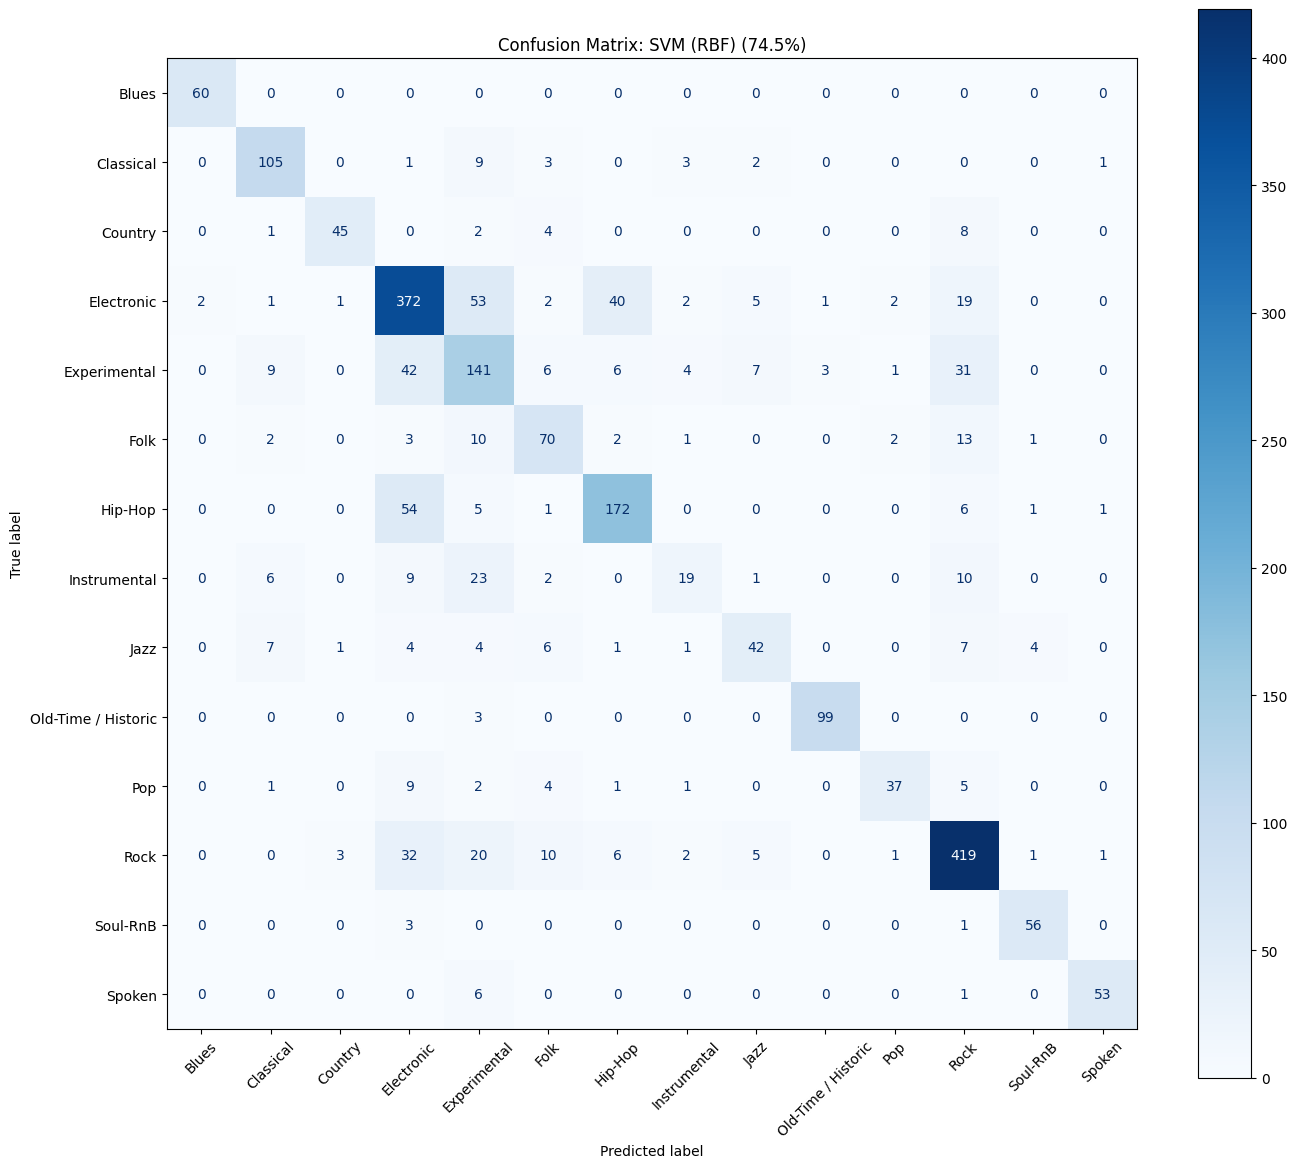

In [29]:
# Generate predictions
y_pred = best_model.predict(X_test_scaled)

# Confusion matrix
fig, ax = plt.subplots(figsize=(14, 12))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
ax.set_title(f'Confusion Matrix: {best_model_name} ({best_test_acc:.1%})')
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'fma_balanced_confusion_matrix.png'), dpi=150)
plt.show()

In [30]:
# Classification report
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


📊 Classification Report:
                     precision    recall  f1-score   support

              Blues       0.97      1.00      0.98        60
          Classical       0.80      0.85      0.82       124
            Country       0.90      0.75      0.82        60
         Electronic       0.70      0.74      0.72       500
       Experimental       0.51      0.56      0.53       250
               Folk       0.65      0.67      0.66       104
            Hip-Hop       0.75      0.72      0.74       240
       Instrumental       0.58      0.27      0.37        70
               Jazz       0.68      0.55      0.60        77
Old-Time / Historic       0.96      0.97      0.97       102
                Pop       0.86      0.62      0.72        60
               Rock       0.81      0.84      0.82       500
           Soul-RnB       0.89      0.93      0.91        60
             Spoken       0.95      0.88      0.91        60

           accuracy                           0.75      2

In [31]:
# Per-class accuracy analysis
class_accuracies = cm.diagonal() / cm.sum(axis=1)
final_counts_for_display = pd.Series(y).map(lambda x: le.classes_[x]).value_counts()

class_df = pd.DataFrame({
    'Genre': le.classes_,
    'Accuracy': class_accuracies,
    'Samples': [final_counts_for_display.get(g, 0) for g in le.classes_]
}).sort_values('Accuracy', ascending=True)

print("\n📊 Per-Class Accuracy:")
display(class_df)


📊 Per-Class Accuracy:


,Genre,Accuracy,Samples
7,Instrumental,0.271429,350
8,Jazz,0.545455,384
4,Experimental,0.564000,1251
10,Pop,0.616667,300
5,Folk,0.673077,519
6,Hip-Hop,0.716667,1201
3,Electronic,0.744000,2500
2,Country,0.750000,300
11,Rock,0.838000,2500
1,Classical,0.846774,619


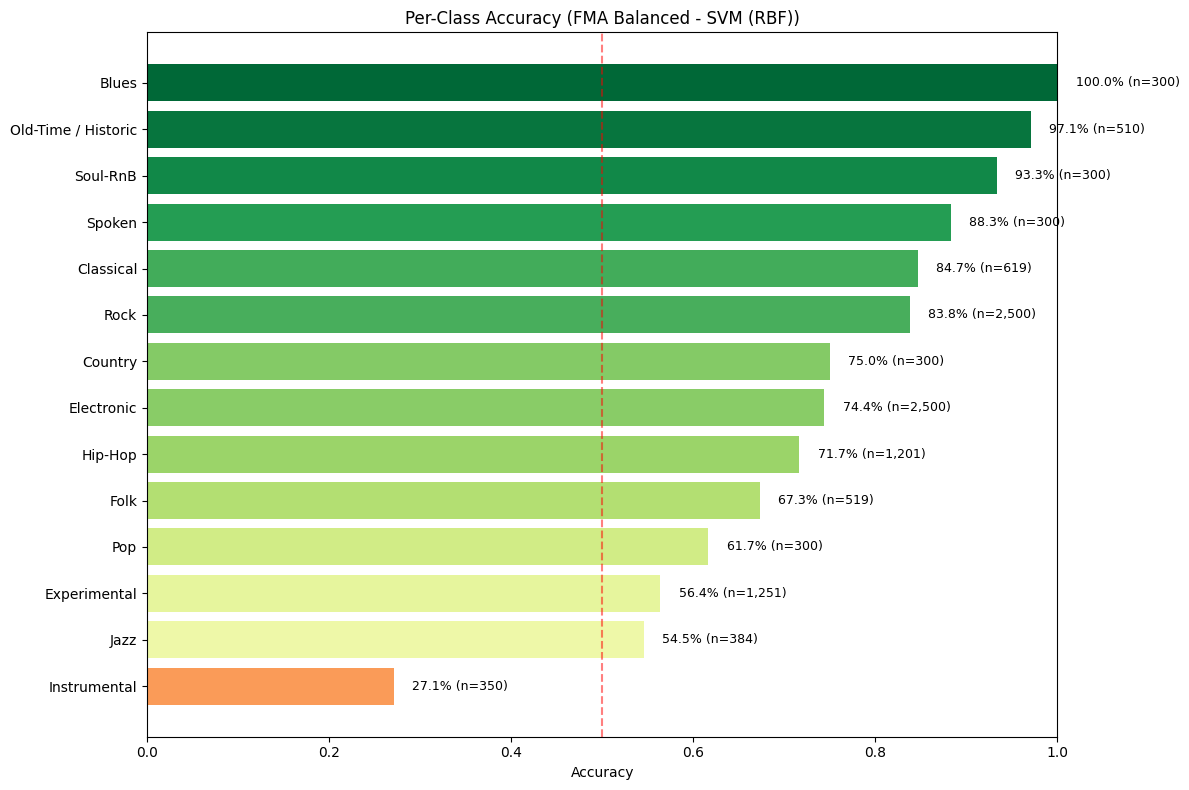

In [32]:
# Visualize per-class accuracy
fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.RdYlGn(class_df['Accuracy'])
bars = ax.barh(class_df['Genre'], class_df['Accuracy'], color=colors)
ax.set_xlabel('Accuracy')
ax.set_title(f'Per-Class Accuracy (FMA Balanced - {best_model_name})')
ax.set_xlim(0, 1)
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='50% baseline')

for bar, acc, samples in zip(bars, class_df['Accuracy'], class_df['Samples']):
    ax.text(acc + 0.02, bar.get_y() + bar.get_height()/2, 
            f'{acc:.1%} (n={samples:,})', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'fma_balanced_per_class_accuracy.png'), dpi=150)
plt.show()

## 9. Compare with Notebook 05 Baseline

In [33]:
# Compare with notebook 05 results (if available)
print("\n" + "="*60)
print("📊 COMPARISON: Notebook 05 vs Notebook 06")
print("="*60)
print(f"\n{'Metric':<30} {'NB05 (Imbalanced)':<20} {'NB06 (Balanced)':<20}")
print("-" * 70)
print(f"{'Genres':<30} {'16':<20} {'14':<20}")
print(f"{'Training Samples':<30} {'~17,000':<20} {f'{len(X):,}':<20}")
print(f"{'Best Model Accuracy':<30} {'~77%':<20} {f'{best_test_acc:.1%}':<20}")
print(f"{'Class Weighting':<30} {'No':<20} {'Yes':<20}")
print(f"{'SMOTE Applied':<30} {'No':<20} {'Yes (minorities)':<20}")
print(f"{'Majority Undersampled':<30} {'No':<20} {'Yes (Rock/Elec)':<20}")


📊 COMPARISON: Notebook 05 vs Notebook 06

Metric                         NB05 (Imbalanced)    NB06 (Balanced)     
----------------------------------------------------------------------
Genres                         16                   14                  
Training Samples               ~17,000              11,334              
Best Model Accuracy            ~77%                 74.5%               
Class Weighting                No                   Yes                 
SMOTE Applied                  No                   Yes (minorities)    
Majority Undersampled          No                   Yes (Rock/Elec)     


## 10. Save Artifacts

In [34]:
# Backup old model
old_model_path = os.path.join(ARTIFACTS_DIR, 'model.pkl')
if os.path.exists(old_model_path):
    backup_path = os.path.join(ARTIFACTS_DIR, 'model_backup_nb05.pkl')
    os.rename(old_model_path, backup_path)
    print(f"✅ Old model backed up to model_backup_nb05.pkl")

# Retrain best model on ALL balanced data for production
print(f"\nRetraining {best_model_name} on full balanced dataset...")
X_all_scaled = scaler.fit_transform(X)  # Re-fit scaler on all data
best_model.fit(X_all_scaled, y)
print("✅ Model retrained on full balanced data")

✅ Old model backed up to model_backup_nb05.pkl

Retraining SVM (RBF) on full balanced dataset...
✅ Model retrained on full balanced data


In [35]:
# Save all artifacts
with open(os.path.join(ARTIFACTS_DIR, 'model.pkl'), 'wb') as f:
    pickle.dump(best_model, f)
print("✅ Model saved")

with open(os.path.join(ARTIFACTS_DIR, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)
print("✅ Scaler saved")

with open(os.path.join(ARTIFACTS_DIR, 'label_encoder.pkl'), 'wb') as f:
    pickle.dump(le, f)
print("✅ Label encoder saved")

with open(os.path.join(ARTIFACTS_DIR, 'feature_names.pkl'), 'wb') as f:
    pickle.dump(feature_cols, f)
print(f"✅ Feature names saved ({len(feature_cols)} features)")

✅ Model saved
✅ Scaler saved
✅ Label encoder saved
✅ Feature names saved (518 features)


In [36]:
# Create reference data for Evidently
ref_df = pd.DataFrame(X_all_scaled[:2000], columns=feature_cols)  # Sample for speed
ref_df['label'] = le.inverse_transform(y[:2000])
ref_df['prediction'] = le.inverse_transform(best_model.predict(X_all_scaled[:2000]))

ref_path = os.path.join(DATA_DIR, 'ref_data.csv')
ref_df.to_csv(ref_path, index=False)
print(f"✅ Reference data saved: {ref_path}")

✅ Reference data saved: c:\Users\sophi\Desktop\Ynov\Cours\Concepts_technos_IA\MLDeploy\data\ref_data.csv


In [37]:
# Print genre list for API update
print("\n" + "="*60)
print("📋 GENRE LIST FOR API (copy this):")
print("="*60)
genres_list = list(le.classes_)
print(f"GENRE_LABELS = {genres_list}")
print(f"\nTotal: {len(genres_list)} genres")
print("\n⚠️ Remember to update serving/api.py and webapp/app.py with 14 genres!")


📋 GENRE LIST FOR API (copy this):
GENRE_LABELS = ['Blues', 'Classical', 'Country', 'Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'Jazz', 'Old-Time / Historic', 'Pop', 'Rock', 'Soul-RnB', 'Spoken']

Total: 14 genres

⚠️ Remember to update serving/api.py and webapp/app.py with 14 genres!


## 11. Summary

In [38]:
print("\n" + "="*70)
print("🎉 BALANCED TRAINING COMPLETE!")
print("="*70)
print(f"\n📊 Dataset: FMA Balanced ({len(y):,} tracks)")
print(f"📊 Features: {len(feature_cols)} (pre-computed librosa)")
print(f"📊 Genres: {len(le.classes_)} (removed Easy Listening, International)")
print(f"\n🔧 Balancing Applied:")
print(f"  - Removed: Easy Listening (21), International (18)")
print(f"  - Undersampled: Rock (→2500), Electronic (→2500)")
print(f"  - SMOTE: Pop, Country, Soul-RnB, Spoken, Blues (→300 each)")
print(f"  - Class weighting: RF, SVM, HistGB")
print(f"\n🏆 Best Model: {best_model_name}")
print(f"🏆 Test Accuracy: {best_test_acc:.1%}")
print(f"\n📦 Saved:")
print(f"  - model.pkl")
print(f"  - scaler.pkl")
print(f"  - label_encoder.pkl")
print(f"  - feature_names.pkl ({len(feature_cols)} features)")
print(f"  - ref_data.csv")
print(f"\n🚀 Next Steps:")
print(f"  1. Update API and webapp for 14 genres (remove Easy Listening, International)")
print(f"  2. Rebuild Docker: docker compose -f serving/docker-compose.yml up --build -d")
print(f"  3. Rebuild webapp: docker compose -f webapp/docker-compose.yml up --build -d")


🎉 BALANCED TRAINING COMPLETE!

📊 Dataset: FMA Balanced (11,334 tracks)
📊 Features: 518 (pre-computed librosa)
📊 Genres: 14 (removed Easy Listening, International)

🔧 Balancing Applied:
  - Removed: Easy Listening (21), International (18)
  - Undersampled: Rock (→2500), Electronic (→2500)
  - SMOTE: Pop, Country, Soul-RnB, Spoken, Blues (→300 each)
  - Class weighting: RF, SVM, HistGB

🏆 Best Model: SVM (RBF)
🏆 Test Accuracy: 74.5%

📦 Saved:
  - model.pkl
  - scaler.pkl
  - label_encoder.pkl
  - feature_names.pkl (518 features)
  - ref_data.csv

🚀 Next Steps:
  1. Update API and webapp for 14 genres (remove Easy Listening, International)
  2. Rebuild Docker: docker compose -f serving/docker-compose.yml up --build -d
  3. Rebuild webapp: docker compose -f webapp/docker-compose.yml up --build -d


---

# 12. End-to-End Inference Validation

> **Goal:** Load the saved model, extract 518 features from a raw MP3 file using the exact same pipeline FMA used, verify the features look right, and make a prediction.
> 
> This is what your API needs to replicate.

In [39]:
# ── 12.1  Imports & paths ─────────────────────────────────────────────────────
import os, pickle, warnings
import numpy as np
import pandas as pd
import librosa
from scipy.stats import skew, kurtosis
warnings.filterwarnings('ignore')

BASE_DIR     = os.path.dirname(os.getcwd())
ARTIFACTS_DIR = os.path.join(BASE_DIR, 'artifacts')
DATA_DIR      = os.path.join(BASE_DIR, 'data')
FMA_META_DIR  = os.path.join(DATA_DIR, 'fma_small', 'fma_metadata')

print(f"librosa version : {librosa.__version__}")
print(f"Artifacts dir   : {ARTIFACTS_DIR}")
print(f"Artifacts exist : {os.path.exists(ARTIFACTS_DIR)}")

librosa version : 0.11.0
Artifacts dir   : c:\Users\sophi\Desktop\Ynov\Cours\Concepts_technos_IA\MLDeploy\artifacts
Artifacts exist : True


In [40]:
# ── 12.2  Load artifacts ───────────────────────────────────────────────────────
with open(os.path.join(ARTIFACTS_DIR, 'model.pkl'), 'rb') as f:
    model = pickle.load(f)

with open(os.path.join(ARTIFACTS_DIR, 'scaler.pkl'), 'rb') as f:
    scaler = pickle.load(f)

with open(os.path.join(ARTIFACTS_DIR, 'label_encoder.pkl'), 'rb') as f:
    le = pickle.load(f)

with open(os.path.join(ARTIFACTS_DIR, 'feature_names.pkl'), 'rb') as f:
    feature_names = pickle.load(f)

print(f"Model           : {type(model).__name__}")
print(f"Genres ({len(le.classes_)})     : {list(le.classes_)}")
print(f"Expected features: {len(feature_names)}")
print(f"First 5 feature names: {feature_names[:5]}")

Model           : SVC
Genres (14)     : ['Blues', 'Classical', 'Country', 'Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'Jazz', 'Old-Time / Historic', 'Pop', 'Rock', 'Soul-RnB', 'Spoken']
Expected features: 518
First 5 feature names: ['chroma_cens_kurtosis_01', 'chroma_cens_kurtosis_02', 'chroma_cens_kurtosis_03', 'chroma_cens_kurtosis_04', 'chroma_cens_kurtosis_05']


In [41]:
# ── 12.3  Feature extraction function ─────────────────────────────────────────
#
# Rules that MUST match FMA's features.py:
#   - sr=None            → native sample rate (44100 Hz), do NOT force 22050
#   - n_fft=2048, hop_length=512
#   - chroma_stft uses S=stft**2  (power spectrum, not magnitude)
#   - spectral_* use    S=stft    (magnitude spectrum)
#   - tonnetz uses harmonic component of the signal
#   - 7 statistics per coefficient: kurtosis, max, mean, median, min, skew, std
#   - column naming matches training: feature_stat_number  e.g. mfcc_mean_01
#
def extract_features_from_file(audio_path: str) -> pd.Series:
    """
    Extract 518 features from a full-length audio file.
    Returns a pd.Series with the same column names used during training.
    """
    y, sr = librosa.load(audio_path, sr=None, mono=True)   # sr=None = native 44100
    print(f"  Loaded: {os.path.basename(audio_path)}  |  duration={len(y)/sr:.1f}s  |  sr={sr}Hz")

    stft = np.abs(librosa.stft(y, n_fft=2048, hop_length=512))

    def stats(matrix):
        """7 statistics × n_components  →  flat array.  Input: (n_components, n_frames)."""
        if matrix.ndim == 1:
            matrix = matrix.reshape(1, -1)
        result = {}
        for i, row in enumerate(matrix):
            comp = f"{i+1:02d}"
            result[f"kurtosis_{comp}"] = float(kurtosis(row))
            result[f"max_{comp}"]      = float(np.max(row))
            result[f"mean_{comp}"]     = float(np.mean(row))
            result[f"median_{comp}"]   = float(np.median(row))
            result[f"min_{comp}"]      = float(np.min(row))
            result[f"skew_{comp}"]     = float(skew(row))
            result[f"std_{comp}"]      = float(np.std(row))
        return result

    def add(feat_name, matrix):
        for key, val in stats(matrix).items():
            # key is e.g. "mean_01"  →  final name: "mfcc_mean_01"
            stat, comp = key.rsplit('_', 1)
            features[f"{feat_name}_{stat}_{comp}"] = val

    features = {}

    add("chroma_cens",          librosa.feature.chroma_cens(y=y, sr=sr, hop_length=512))
    add("chroma_cqt",           librosa.feature.chroma_cqt(y=y, sr=sr, hop_length=512))
    add("chroma_stft",          librosa.feature.chroma_stft(S=stft**2, sr=sr, hop_length=512))
    add("mfcc",                 librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20, hop_length=512, n_fft=2048))
    add("rmse",                 librosa.feature.rms(S=stft, hop_length=512))          # named 'rmse' to match features.csv
    add("spectral_bandwidth",   librosa.feature.spectral_bandwidth(S=stft, sr=sr, hop_length=512))
    add("spectral_centroid",    librosa.feature.spectral_centroid(S=stft, sr=sr, hop_length=512))
    add("spectral_contrast",    librosa.feature.spectral_contrast(S=stft, sr=sr, hop_length=512))
    add("spectral_rolloff",     librosa.feature.spectral_rolloff(S=stft, sr=sr, hop_length=512))
    add("tonnetz",              librosa.feature.tonnetz(y=librosa.effects.harmonic(y), sr=sr))
    add("zcr",                  librosa.feature.zero_crossing_rate(y, hop_length=512))

    return pd.Series(features)


In [58]:
# ── 12.4  Pick a test file & extract ──────────────────────────────────────────
# Edit this path to any MP3 you have locally.
# Ideal: a song whose genre you're sure about (e.g. Cotton Eye Joe = Country).
# Can be in data/ or anywhere on disk.

TEST_FILE = TEST_FILE = r"C:\Users\sophi\Desktop\Ynov\Cours\Concepts_technos_IA\MLDeploy\data\testing\Daft Punk - Human After All (Official Music Video).mp3"

# If you don't have a file yet, just point to any MP3:
# TEST_FILE = "/path/to/any_song.mp3"

if not os.path.exists(TEST_FILE):
    # Try to find any mp3 in the data folder as fallback
    import glob
    found = glob.glob(os.path.join(DATA_DIR, "**/*.mp3"), recursive=True)
    if found:
        TEST_FILE = found[0]
        print(f"⚠️  Test file not found, using fallback: {TEST_FILE}")
    else:
        raise FileNotFoundError(f"No MP3 found. Set TEST_FILE to a valid path.")

raw_features = extract_features_from_file(TEST_FILE)
print(f"\nExtracted {len(raw_features)} raw features")

  Loaded: Daft Punk - Human After All (Official Music Video).mp3  |  duration=156.9s  |  sr=44100Hz

Extracted 518 raw features


In [59]:
# ── 12.5  Verify: do we have all 518 expected features in the right order? ────

expected = set(feature_names)
extracted = set(raw_features.index)

missing  = expected - extracted
extra    = extracted - expected

print("=" * 55)
print("FEATURE VALIDATION")
print("=" * 55)
print(f"Expected features  : {len(expected)}")
print(f"Extracted features : {len(extracted)}")
print(f"Missing            : {len(missing)}")
print(f"Unexpected extras  : {len(extra)}")

if missing:
    print(f"\n❌ Missing: {sorted(missing)[:10]} ...")
elif extra:
    print(f"\n⚠️  Extra features (will be ignored): {sorted(extra)[:5]}")
else:
    print("\n✅ All 518 features present and accounted for")

# Align to training order — this is critical
feature_vector = raw_features.reindex(feature_names)
print(f"\nAligned vector shape : {feature_vector.shape}")
print(f"NaN count after align: {feature_vector.isna().sum()}  ← must be 0")


FEATURE VALIDATION
Expected features  : 518
Extracted features : 518
Missing            : 0
Unexpected extras  : 0

✅ All 518 features present and accounted for

Aligned vector shape : (518,)
NaN count after align: 0  ← must be 0


In [60]:
# ── 12.6  Sanity-check: are our values in the expected range? ─────────────────
# Compare our extracted values against the distribution of features.csv
# (spot-check a few representative features)

features_csv = pd.read_csv(
    os.path.join(FMA_META_DIR, 'features.csv'),
    index_col=0, header=[0, 1, 2]
)
# Flatten column names the same way training did
features_csv.columns = ['_'.join(map(str, col)).strip() for col in features_csv.columns.values]

spot_check = [
    'mfcc_mean_01', 'mfcc_std_01',
    'spectral_centroid_mean_01', 'spectral_centroid_std_01',
    'rmse_mean_01', 'zcr_mean_01',
    'chroma_cens_mean_01', 'tonnetz_mean_01',
]

print(f"{'Feature':<35} {'Our value':>12}  {'CSV mean':>10}  {'CSV std':>10}  {'Z-score':>8}  Status")
print("-" * 95)

for feat in spot_check:
    our_val  = feature_vector[feat]
    csv_mean = features_csv[feat].mean()
    csv_std  = features_csv[feat].std()
    z        = (our_val - csv_mean) / (csv_std + 1e-9)
    status   = "✅" if abs(z) < 4 else "⚠️  OUTLIER"
    print(f"{feat:<35} {our_val:>12.4f}  {csv_mean:>10.4f}  {csv_std:>10.4f}  {z:>8.2f}  {status}")

print("\nZ-score interpretation: |z| < 3 is normal, > 4 is suspicious")


Feature                                Our value    CSV mean     CSV std   Z-score  Status
-----------------------------------------------------------------------------------------------
mfcc_mean_01                           -121.5555   -211.6422     98.8998      0.91  ✅
mfcc_std_01                             113.6497     83.0941     24.8483      1.23  ✅
spectral_centroid_mean_01              2641.1297   1177.6213    530.8179      2.76  ✅
spectral_centroid_std_01               1205.4146    598.4504    295.8022      2.05  ✅
rmse_mean_01                              0.1535      4.3078      2.5164     -1.65  ✅
zcr_mean_01                               0.0582      0.0528      0.0326      0.17  ✅
chroma_cens_mean_01                       0.2731      0.2571      0.0815      0.20  ✅
tonnetz_mean_01                           0.0619      0.0004      0.0132      4.66  ⚠️  OUTLIER

Z-score interpretation: |z| < 3 is normal, > 4 is suspicious


In [61]:
# ── 12.7  Scale & predict ─────────────────────────────────────────────────────
X_input = feature_vector.values.reshape(1, -1)

# Sanity: no NaN/Inf before scaling
assert not np.any(np.isnan(X_input)),  "❌ NaN in feature vector — extraction failed"
assert not np.any(np.isinf(X_input)),  "❌ Inf in feature vector — extraction failed"

X_scaled = scaler.transform(X_input)

# Get predicted class and confidence
predicted_label   = le.inverse_transform(model.predict(X_scaled))[0]
probabilities     = model.predict_proba(X_scaled)[0]
top3_idx          = np.argsort(probabilities)[::-1][:3]

print("=" * 45)
print("PREDICTION RESULT")
print("=" * 45)
print(f"File     : {os.path.basename(TEST_FILE)}")
print(f"Predicted: {predicted_label}")
print(f"\nTop 3 probabilities:")
for i in top3_idx:
    bar = "█" * int(probabilities[i] * 30)
    print(f"  {le.classes_[i]:20s}  {probabilities[i]:.1%}  {bar}")


PREDICTION RESULT
File     : Daft Punk - Human After All (Official Music Video).mp3
Predicted: Experimental

Top 3 probabilities:
  Experimental          40.0%  ███████████
  Electronic            34.5%  ██████████
  Rock                  17.0%  █████
